In [ ]:
#!pip install lightgbm 

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import json
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
# read in optimal bin data
with open("optimal_bins.json", "r") as f:
    optimal_bins = json.load(f)

In [38]:
data.shape

(49500, 5)

In [27]:
optimal_bins['CPUE']

[[-1.0, -0.999],
 [-0.999, -0.96],
 [-0.96, -0.9239999999999999],
 [-0.9239999999999999, -0.9139999999999999],
 [-0.9139999999999999, -0.8899999999999999],
 [-0.8899999999999999, -0.8779999999999999]]

In [49]:
(np.round(data['biomass'], 3) > -0.2).sum()


np.int64(20)

In [39]:
np.max(data['biomass'])

np.float64(-0.00576424)

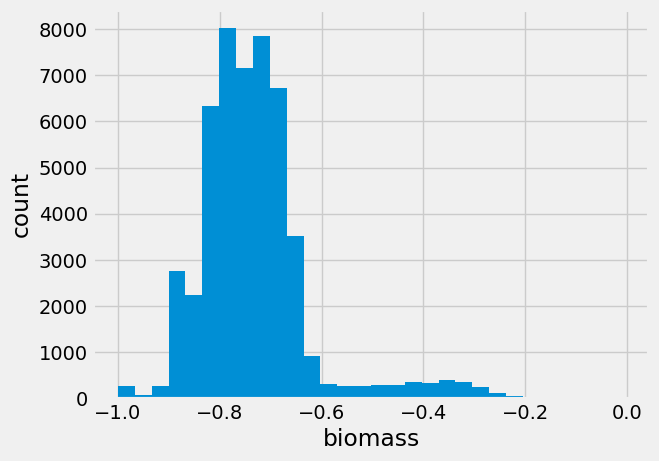

In [33]:
plt.hist(data['biomass'], bins=30)
plt.xlabel('biomass')
plt.ylabel('count')
plt.show()


In [50]:
data_sub = data[data['biomass'] > -0.2]

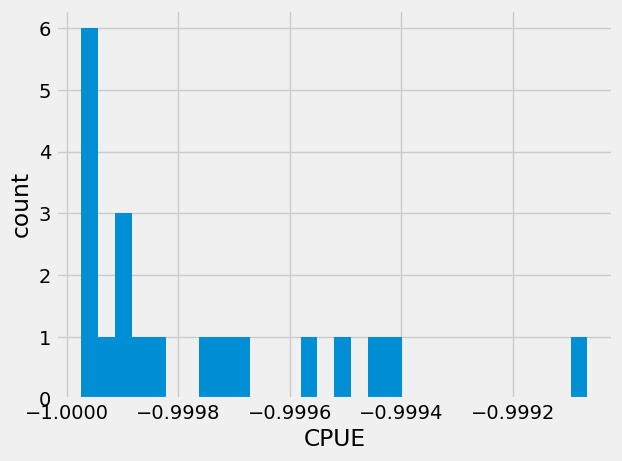

In [51]:
plt.hist(data_sub['CPUE'], bins=30)
plt.xlabel('CPUE')
plt.ylabel('count')
plt.show()

In [36]:
data_sub.head()

,months,act0,act1,CPUE,biomass
0,3,-0.911334,-0.843671,-1.0,-1.0
1,4,-0.964028,-0.703425,-1.0,-1.0
2,5,-0.964028,-0.904936,-1.0,-1.0
3,6,-0.884734,-0.851039,-1.0,-1.0
4,7,-0.839049,-0.761919,-1.0,-1.0


In [3]:
# read in continuous data
data = pd.read_csv("tqc_clean.csv")
data = data[['months', 'act0', 'act1', 'CPUE', 'biomass']]
data.head()

,months,act0,act1,CPUE,biomass
0,3,-0.911334,-0.843671,-1.0,-1.0
1,4,-0.964028,-0.703425,-1.0,-1.0
2,5,-0.964028,-0.904936,-1.0,-1.0
3,6,-0.884734,-0.851039,-1.0,-1.0
4,7,-0.839049,-0.761919,-1.0,-1.0


In [4]:
# remove anomolous biomass data
data = data[(data['biomass'] != -1) & (data['biomass'] <= -0.2)]

In [5]:
# create functions for mapping continuous data to optimal bins

all_vars = ['act0', 'act1', 'CPUE', 'biomass']

# find which bin a value falls into and return the index
def bin_mapper(val, bins):
    
    def one_hot_encode(curr_bin, all_bins):
        return all_bins.index(curr_bin)
        
    for curr_bin in bins:
        left, right = curr_bin
        if left <= val < right:
            return one_hot_encode(curr_bin, bins)
    return len(bins)

# function for getting optimal bins
def find_optimal_bins(row, var):
    bin_set = optimal_bins[var]
    return bin_mapper(row[var], bin_set)

def preprocess_data(data):    
    for var in all_vars:
        find_optimal_bins_for_var = lambda row: find_optimal_bins(row, var)
        data[f"{var}_bin"] = data.apply(find_optimal_bins_for_var, axis=1)
    data = data.drop(columns=all_vars)
    return data


In [6]:
# pre-process data with optimal bin indices
preprocessed_data = preprocess_data(data.copy())
preprocessed_data.head()

,months,act0_bin,act1_bin,CPUE_bin,biomass_bin
11,5,0,1,0,0
12,6,0,3,0,0
13,7,4,4,2,0
14,8,4,3,5,0
15,9,1,2,5,0


In [7]:
# set up train/test splits for models that predict the action from the current state (i.e., month, CPUE, biomass)
SEED = 42
X, y0, y1 = preprocessed_data[['months', 'CPUE_bin', 'biomass_bin']], preprocessed_data['act0_bin'], preprocessed_data['act1_bin']
X0_train, X0_test, y0_train, y0_test = train_test_split(X, y0, test_size=0.2, random_state=SEED, stratify=y0)
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=SEED, stratify=y1)

In [8]:
# train LightGBM classifier to predict minnow (act0) bin from the state features
lgb_model_minnow = LGBMClassifier(
    objective="multiclass", # predict one of several bin classes
    num_class=y0_train.nunique(), # number of distinct action bins
    n_estimators=200, # number of boosting rounds
    learning_rate=0.05, # learning rate
    num_leaves=31, # max leaves per tree
    random_state=SEED
)

lgb_model_minnow.fit(
    X0_train,
    y0_train,
    categorical_feature=["months", "CPUE_bin", "biomass_bin"] # treat columns as categories
)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001286 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21
[LightGBM] [Info] Number of data points in the train set: 39398, number of used features: 3
[LightGBM] [Info] Start training from score -0.065693
[LightGBM] [Info] Start training from score -3.482269
[LightGBM] [Info] Start training from score -5.564190
[LightGBM] [Info] Start training from score -5.339723
[LightGBM] [Info] Start training from score -3.720807
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,learning_rate,0.05
,n_estimators,200
,objective,'multiclass'
,random_state,42
,num_class,5
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [9]:
# train LightGBM classifier to predict fukui (act1) bin from the state features
lgb_model_fukui = LGBMClassifier(
    objective="multiclass",
    num_class=y1_train.nunique(),
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)

lgb_model_fukui.fit(
    X1_train,
    y1_train,
    categorical_feature=["months", "CPUE_bin", "biomass_bin"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21
[LightGBM] [Info] Number of data points in the train set: 39398, number of used features: 3
[LightGBM] [Info] Start training from score -0.811743
[LightGBM] [Info] Start training from score -1.156099
[LightGBM] [Info] Start training from score -1.774747
[LightGBM] [Info] Start training from score -2.681946
[LightGBM] [Info] Start training from score -5.729440
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

,learning_rate,0.05
,n_estimators,200
,objective,'multiclass'
,random_state,42
,num_class,5
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [10]:
# return most likely bin class and probability for each data point
lgb_y0_pred = lgb_model_minnow.predict(X0_test)
lgb_y0_prob = lgb_model_minnow.predict_proba(X0_test)

lgb_y1_pred = lgb_model_fukui.predict(X1_test)
lgb_y1_prob = lgb_model_fukui.predict_proba(X1_test)

In [11]:
# get accuracy metrics
lgb_y0_acc = accuracy_score(y0_test, lgb_y0_pred)
lgb_y0_f1 = f1_score(y0_test, lgb_y0_pred, average='weighted')
lgb_y0_mae_bins = np.mean(np.abs(y0_test.to_numpy() - lgb_y0_pred))

lgb_y1_acc = accuracy_score(y1_test, lgb_y1_pred)
lgb_y1_f1 = f1_score(y1_test, lgb_y1_pred, average='weighted')
lgb_y1_mae_bins = np.mean(np.abs(y1_test.to_numpy() - lgb_y1_pred))

metrics_df = pd.DataFrame([
    {"model": "minnow", "accuracy": lgb_y0_acc, "weighted_f1": lgb_y0_f1, "mae_bins": lgb_y0_mae_bins},
    {"model": "fukui",  "accuracy": lgb_y1_acc, "weighted_f1": lgb_y1_f1, "mae_bins": lgb_y1_mae_bins},
])

metrics_df.to_csv("lgb_metrics.csv", index=False)

In [12]:
# set up plot data
minnow_df = X0_test.copy()
minnow_df['actual'] = y0_test
minnow_df['lgb_pred'] = lgb_y0_pred

fukui_df = X1_test.copy()
fukui_df['actual'] = y1_test
fukui_df['lgb_pred'] = lgb_y1_pred

month_dict = {3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8:"August", 9: "September", 10: "October", 11: "November"}
trap_dfs = [minnow_df, fukui_df]
trap_dict = {0: "Minnow", 1: "Fukui"}


In [ ]:
# get bin labels
cpue_labels = [f"[{b[0]:.3f}, {b[1]:.3f})" for b in optimal_bins['CPUE']]
biomass_labels = [f"[{b[0]:.3f}, {b[1]:.3f})" for b in optimal_bins['biomass']]

# get bin indices
cpue_indices = list(range(len(optimal_bins['CPUE'])))
biomass_indices = list(range(len(optimal_bins['biomass'])))

# extract boundary values from bins
cpue_boundaries = [b[0] for b in optimal_bins['CPUE']] + [optimal_bins['CPUE'][-1][1]]
biomass_boundaries = [b[0] for b in optimal_bins['biomass']] + [optimal_bins['biomass'][-1][1]]

In [16]:
# convert boundaries to real scale
params = {
    'max_action': 3000,
    'smin': 5,
    'smax': 110
}

def calc_biomass(y):
    return max(0, -0.071 * y + 0.003 * y**2 + 0.00002 * y**3)

bmin = calc_biomass(params['smin'])
bmax = calc_biomass(params['smax'])

# get action midpoints
action0_midpoints_real = [max(params['max_action'] * (1 + (b[0] + b[1]) / 2) / 2, 0) for b in optimal_bins['act0']]
action1_midpoints_real = [max(params['max_action'] * (1 + (b[0] + b[1]) / 2) / 2, 0) for b in optimal_bins['act1']]

action_midpoints_real_list = [action0_midpoints_real, action1_midpoints_real]


# convert biomass boundaries
biomass_boundaries_real = [(v + 1) * (bmax - bmin) / 2 + bmin for v in biomass_boundaries]

# convert CPUE boundaries
cpue_boundaries_real = [(v + 1) / 2 * 100 for v in cpue_boundaries]


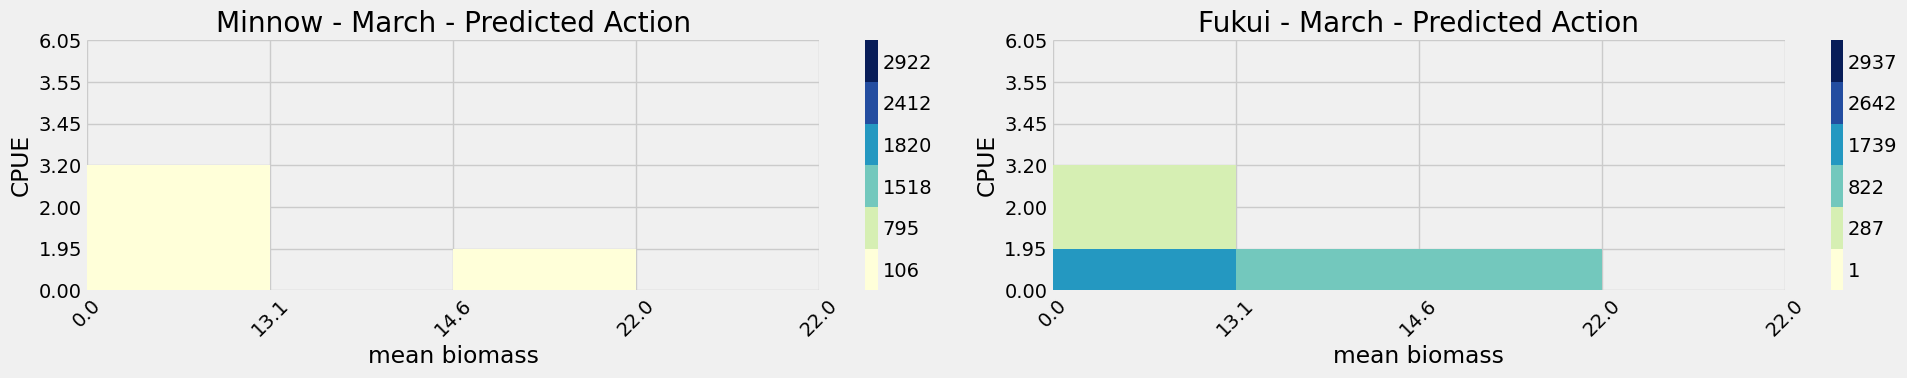

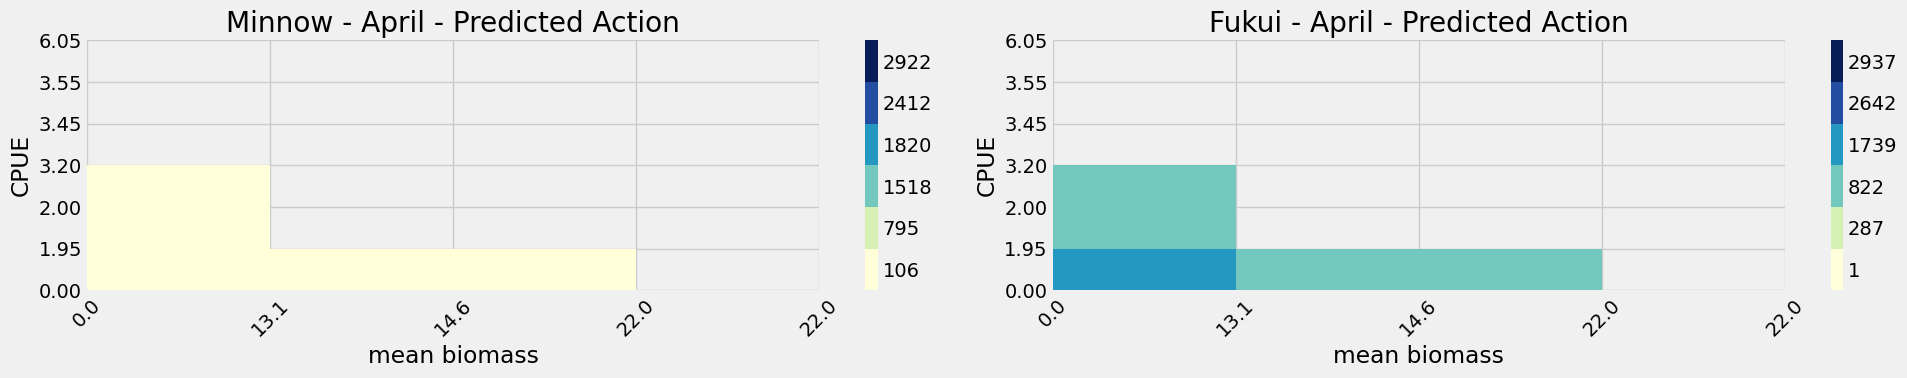

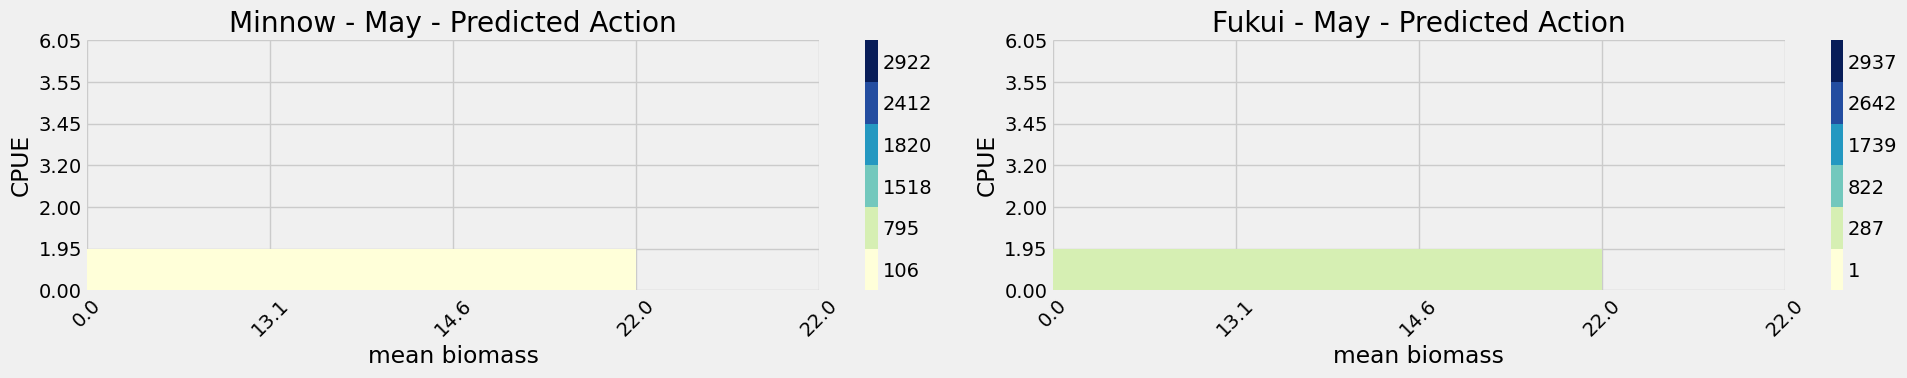

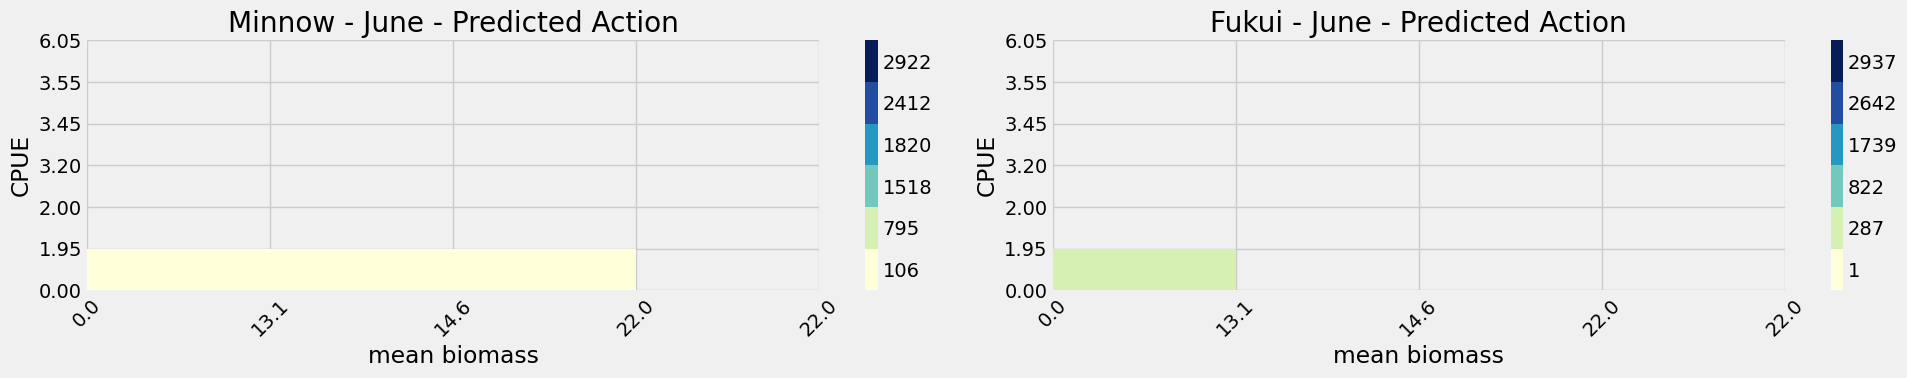

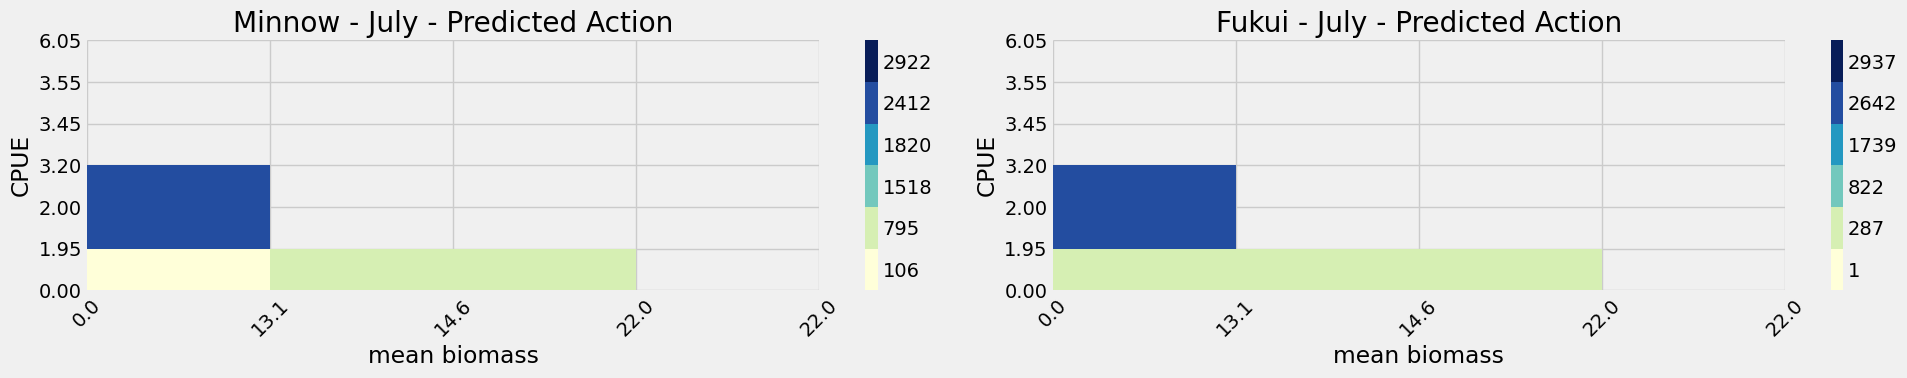

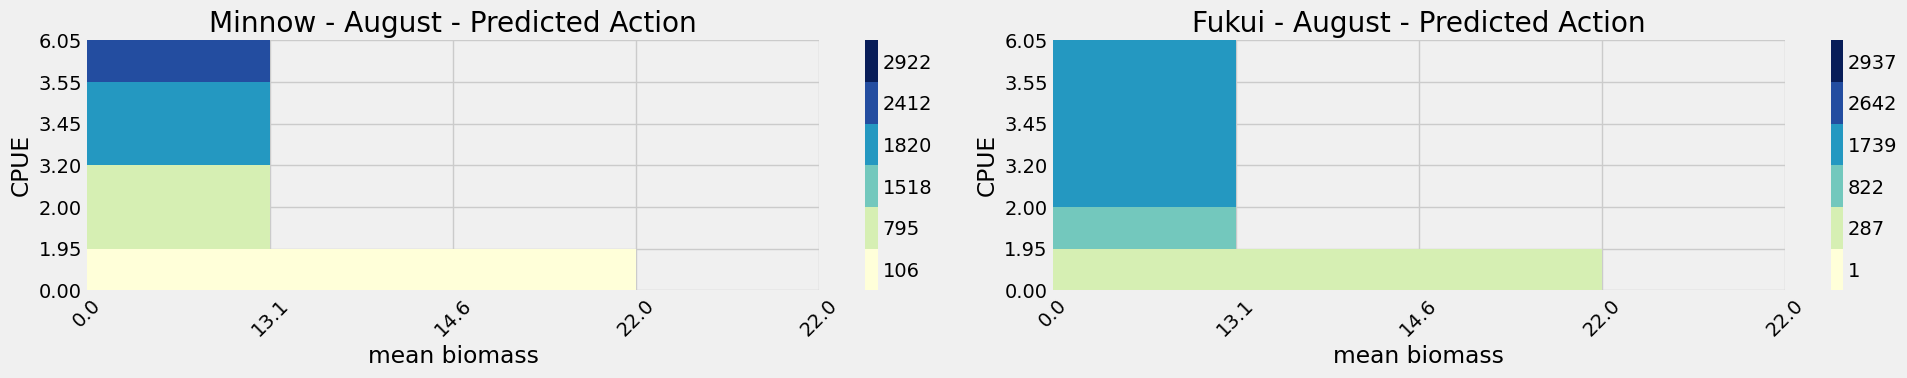

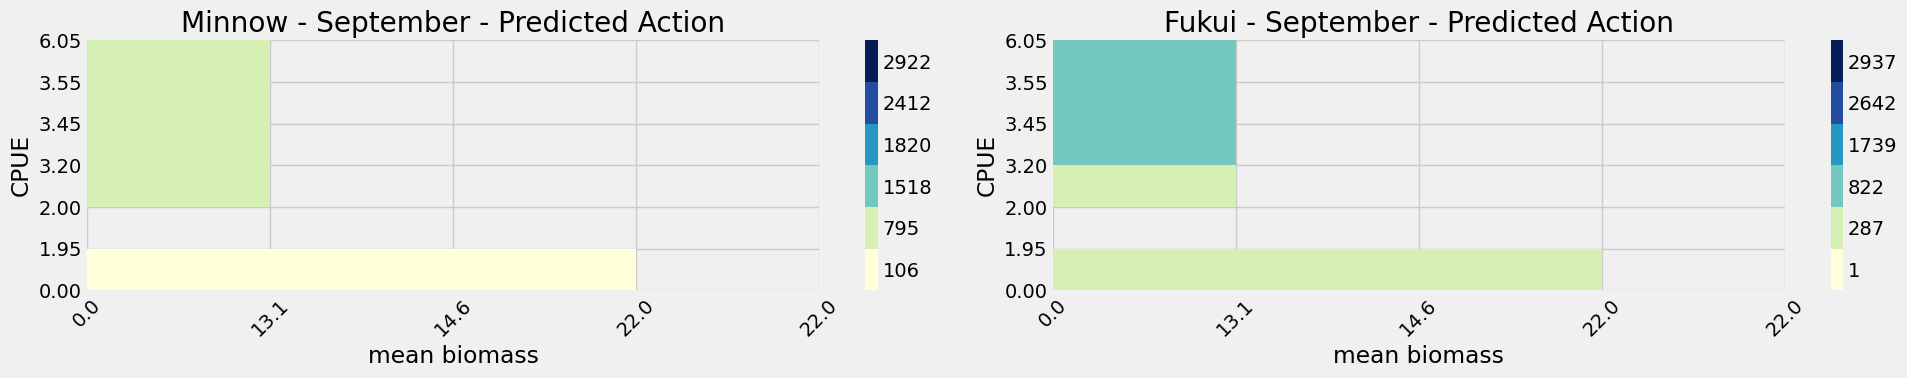

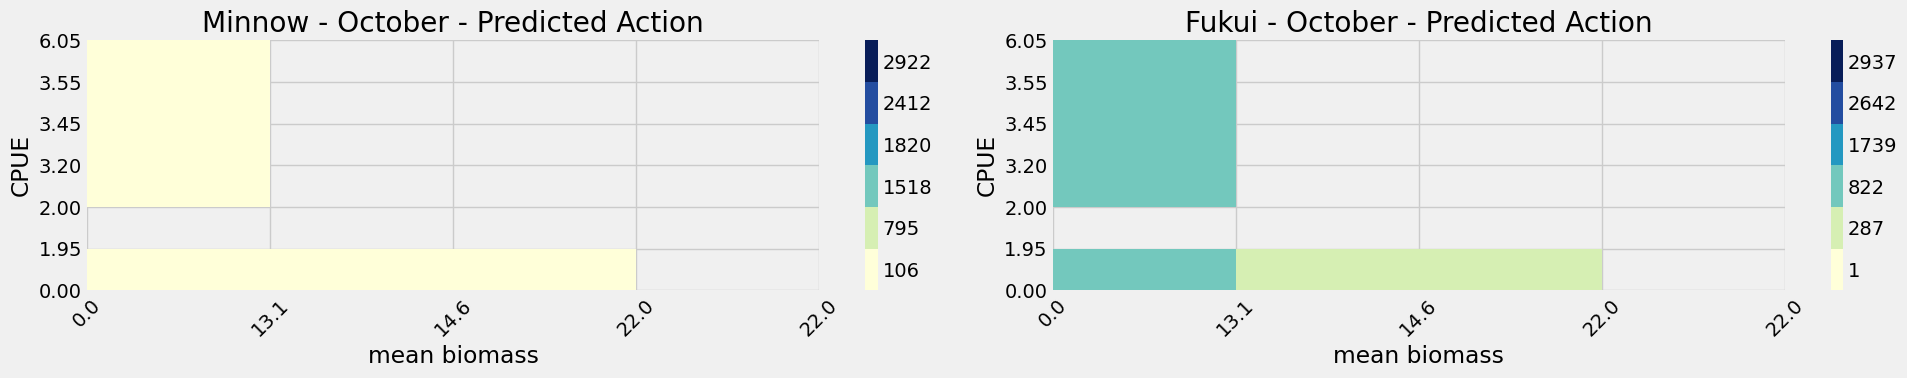

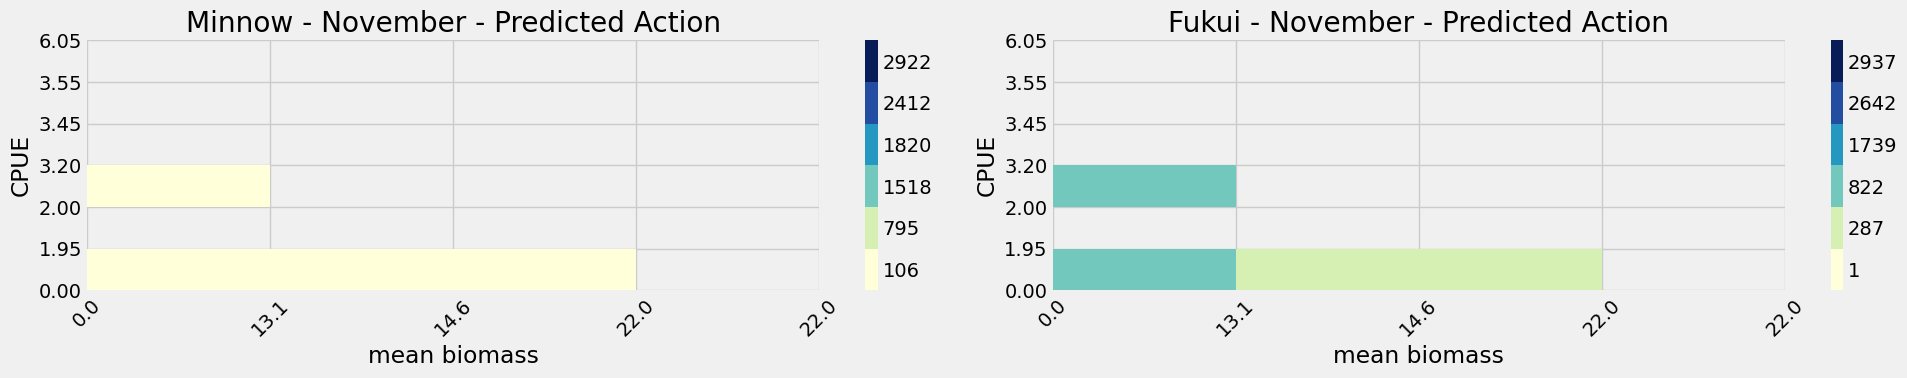

In [20]:
n_classes = len(optimal_bins['act0'])
cmap = plt.get_cmap("YlGnBu", n_classes)


for month in month_dict.keys():
    fig, axes = plt.subplots(1, 2, figsize=(20, 4))
    for i in range(2):
        df = trap_dfs[i]
        curr_month = df[df["months"] == month]

        lgb_preds = pd.pivot_table(data=curr_month, index="CPUE_bin", columns="biomass_bin", values="lgb_pred", aggfunc=lambda x: x.mode().iloc[0])
        lgb_preds = lgb_preds.reindex(index=cpue_indices, columns=biomass_indices)

        sns.heatmap(lgb_preds, annot=False, cmap=cmap, vmin=-0.5, vmax=5.5,
                    ax=axes[i], xticklabels=False, yticklabels=False)

        axes[i].set_xticks(range(len(biomass_boundaries_real)))
        axes[i].set_xticklabels([f"{v:.1f}" for v in biomass_boundaries_real], rotation=45)
        axes[i].set_yticks(range(len(cpue_boundaries_real)))
        axes[i].set_yticklabels([f"{v:.2f}" for v in cpue_boundaries_real])
        axes[i].invert_yaxis()

        cbar = axes[i].collections[0].colorbar
        cbar.set_ticks(range(len(action_midpoints_real_list[i])))
        cbar.set_ticklabels([f"{v:.0f}" for v in action_midpoints_real_list[i]])

        axes[i].set_title(f"{trap_dict[i]} - {month_dict[month]} - Predicted Action")
        axes[i].set_xlabel("mean biomass")
        axes[i].set_ylabel("CPUE")

    plt.tight_layout()
    plt.show()


